# EDA & PREPROCESSING

In [7]:


import pandas as pd

df = pd.read_csv("/content/Data Sentimen MBG (1).csv")
df.head()

,author,published_at,like_count,text,public,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,@Ipank049,2026-03-15T19:00:49Z,0,Penguasa dan Pelaksana Program MBG menjadi Pen...,Negatif,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,@Tmsaja873,2026-03-15T11:15:42Z,0,anaknya makan 1x bapaknya penganguran..,Negatif,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Negatif
2,@fakhrieofisial4819,2026-03-15T07:36:34Z,0,"Rusak lah negara kalau Nepotisme, korupsi sema...",Negatif,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,@sudaryadidar1358,2026-03-14T08:23:35Z,0,Programpresiden jokowi. Berobat gratid banyak ...,Negatif,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,@KokGiniAmat,2026-03-14T06:33:38Z,0,Maling Berkedok Gizi,Negatif,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:

df.columns

Index(['author', 'published_at', 'like_count', 'text', 'public', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12'],
      dtype='str')

In [9]:
# Hapus kolom kosong
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Rename biar konsisten
df.rename(columns={'text': 'comment'}, inplace=True)

# Cek hasil
print(df.columns)

Index(['author', 'published_at', 'like_count', 'comment', 'public'], dtype='str')


In [10]:
df.columns

Index(['author', 'published_at', 'like_count', 'comment', 'public'], dtype='str')

# Cleaning

In [11]:
import re

def text_cleaning(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)  # hapus URL
    text = re.sub(r'@\w+', '', text)     # hapus mention
    text = re.sub(r'#', '', text)        # hapus simbol hashtag
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # hapus simbol & angka
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['comment'].apply(text_cleaning)

# NORMALIZATION

In [12]:
slang_dict = {
    "yg": "yang",
    "gk": "tidak",
    "ga": "tidak",
    "bgt": "banget",
    "kuy": "ayo",
    "mantul": "mantap"
}

def normalize_text(text):
    words = text.split()
    normalized = [slang_dict[word] if word in slang_dict else word for word in words]
    return " ".join(normalized)

df['clean_text'] = df['clean_text'].apply(normalize_text)

#TOKENIZATION

In [13]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [14]:
from nltk.tokenize import word_tokenize

df['tokens'] = df['clean_text'].apply(word_tokenize)

In [15]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')

df['tokens'] = df['clean_text'].apply(word_tokenize)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# STOPWORD REMOVAL

In [16]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stop_factory = StopWordRemoverFactory()
stopwords = set(stop_factory.get_stop_words())

df['tokens'] = df['tokens'].apply(
    lambda words: [word for word in words if word not in stopwords]
)

# STEMMING

In [25]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

df['tokens'] = df['tokens'].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

In [26]:
df['clean_text'] = df['tokens'].apply(lambda x: " ".join(x))

# EDA

# Panjang Komentar

In [18]:
!pip install numpy==1.26.4

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
!pip install --upgrade matplotlib seaborn

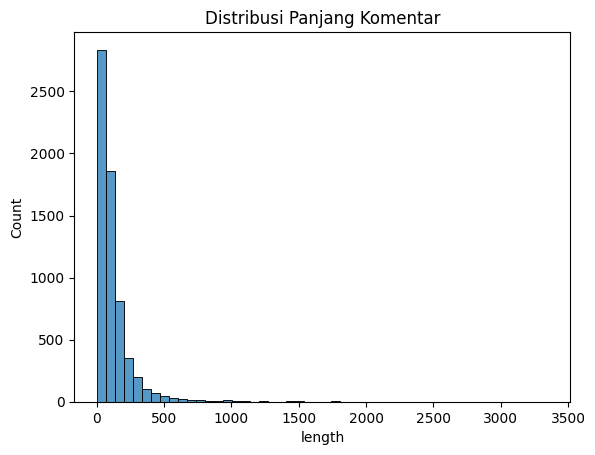

In [19]:
df['length'] = df['comment'].apply(len)

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['length'], bins=50)
plt.title("Distribusi Panjang Komentar")
plt.show()

# Distribusi Jumlah Kata

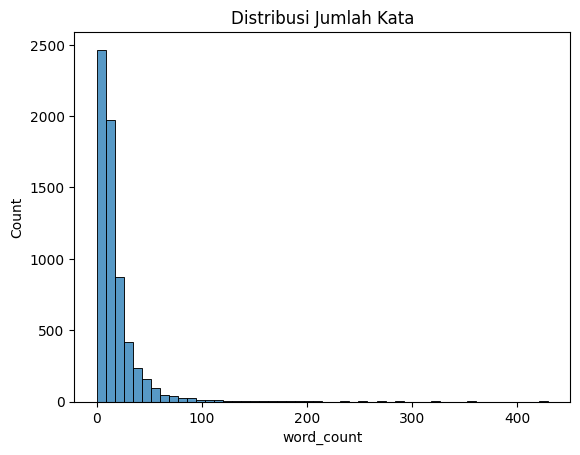

In [20]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

sns.histplot(df['word_count'], bins=50)
plt.title("Distribusi Jumlah Kata")
plt.show()

# Kata Terbanyak

In [21]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()
word_freq = Counter(all_words)

print(word_freq.most_common(10))

[('yang', 3305), ('mbg', 2078), ('di', 1845), ('dan', 1775), ('ini', 1356), ('tidak', 1072), ('ada', 1011), ('program', 970), ('itu', 826), ('rakyat', 744)]


# WordCloud

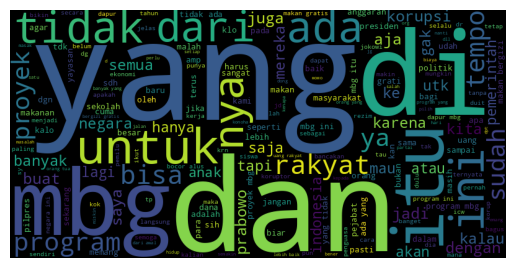

In [22]:
from wordcloud import WordCloud

text = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis('off')
plt.show()

# Labeling

In [23]:
def labeling(text):
    if any(word in text for word in ['bagus', 'mantap', 'keren']):
        return 'positif'
    elif any(word in text for word in ['buruk', 'jelek', 'parah']):
        return 'negatif'
    else:
        return 'netral'

df['label'] = df['clean_text'].apply(labeling)

In [24]:
df.to_csv("clean_data.csv", index=False)

<Axes: xlabel='label', ylabel='count'>

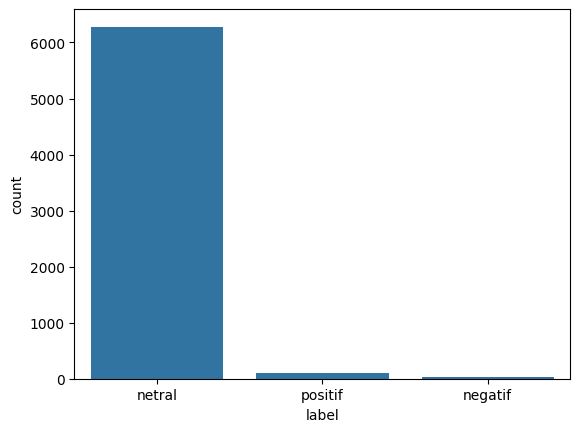

In [ ]:
import seaborn as sns
sns.countplot(x=TARGET_COLUMN, data=df)